Exercise: Outlier Detection and Removal using Quantile, Standard Deviation, Z-score and IQR Methods

Problem Statement: Outlier Detection and Removal using various methods

You have been provided with a dataset `customer_profile.csv` containing features such as `Age`, `Income`, and `Spending_Score`.

Your task is to identify and remove outliers from these features using multiple data cleaning methods.

Tasks to be Performed:

1.  Quantile Method: Remove the most extreme outliers using the `[0.001, 0.999]` percentile range on the `Income` feature.
2.  Standard Deviation Method: Apply the Standard Deviation method with a threshold of 3 on the `Spending_Score` feature.
3.  Z-Score Method (Manual): Calculate Z-scores manually and use a threshold of `|Z| > 3` to remove outliers from the `Age` feature.
4.  Interquartile Range (IQR) Method: Use the IQR method to identify and remove outliers from the `Income` feature.
5.  Visualize and Compare: Use plots to visualize the data distribution before and after each method to understand the effect of outlier removal.

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import norm



In [3]:
df = pd.read_csv('customer_profile - customer_profile.csv')

In [4]:
df.describe()

,Age,Income,Spending_Score
count,504.000000,504.000000,504.000000
mean,35.047996,51376.380710,52.588979
std,10.264667,20605.775549,22.554853
min,-10.000000,5000.000000,-7.925108
25%,27.965428,41070.623905,37.887192
50%,35.127971,50438.757215,52.396117
75%,41.367833,59939.196162,65.179705
max,85.000000,300000.000000,250.000000


Text(0.5, 1.0, 'Spending score')

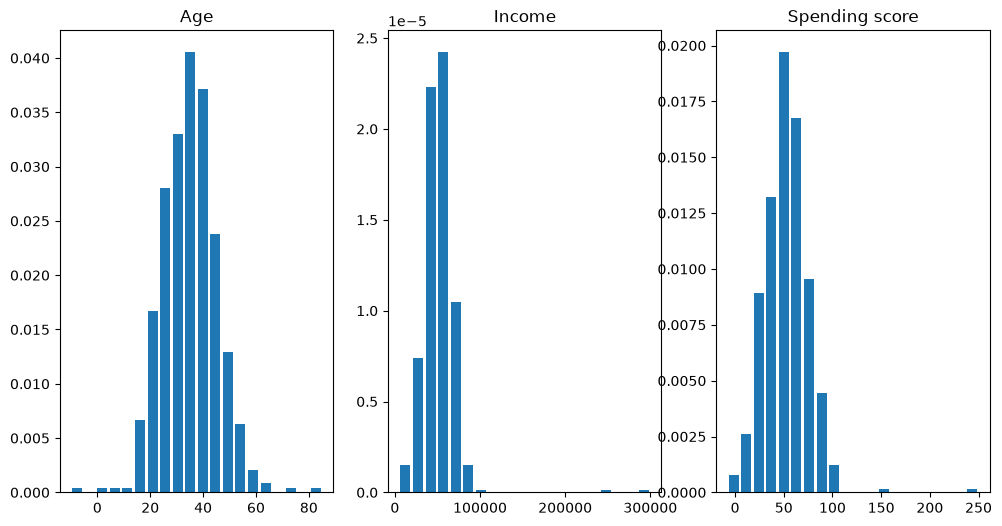

In [8]:
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.hist(df['Age'], bins=20, rwidth=0.8, density=True)
plt.title("Age")

plt.subplot(1,3,2)
plt.hist(df['Income'], bins=20, rwidth=0.8, density=True)
plt.title("Income")
plt.subplot(1,3,3)
plt.hist(df['Spending_Score'], bins=20, rwidth=0.8, density=True)
plt.title("Spending score")

### Quantile - Income 0.001-0.999

In [10]:
lower_treshold = df['Income'].quantile(0.001)
upper_treshold = df['Income'].quantile(0.999)

In [11]:
outliers_quantile_income = df[(df['Income'] < lower_treshold) | (df['Income'] > upper_treshold)]
outliers_quantile_income.head()

,Age,Income,Spending_Score
501,15.0,5000.0,150.0
503,-10.0,300000.0,10.0


In [14]:
df_quantile_income = df[(df['Income'] >= lower_treshold) & (df['Income'] <= upper_treshold)]
df_quantile_income.info()
print("cleaned : ",df_quantile_income.shape[0])
print("Original : ",df.shape[0])

<class 'pandas.DataFrame'>
Index: 502 entries, 0 to 502
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             502 non-null    float64
 1   Income          502 non-null    float64
 2   Spending_Score  502 non-null    float64
dtypes: float64(3)
memory usage: 15.7 KB
cleaned :  502
Original :  504


Text(0.5, 1.0, 'Cleaned data')

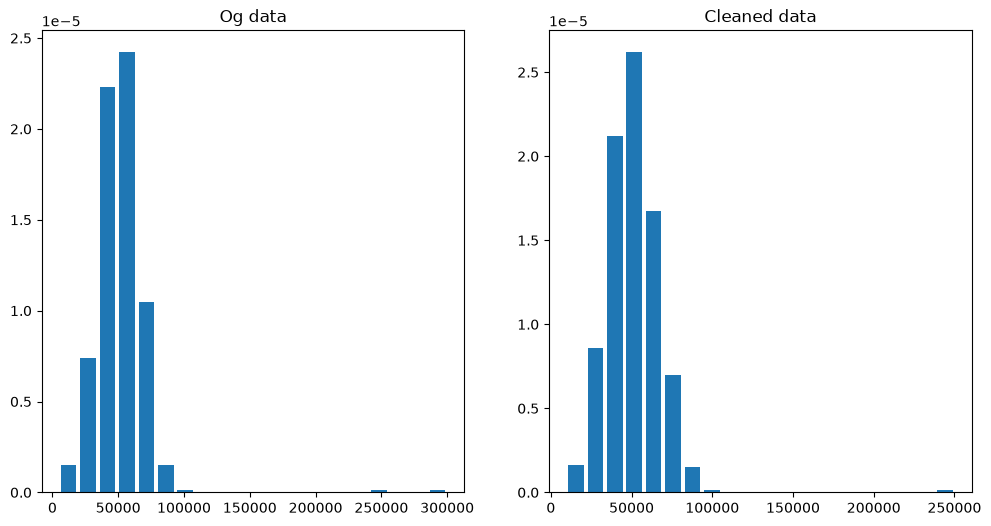

In [13]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.hist(df['Income'], bins=20, rwidth=0.8, density=True)
plt.title("Og data")

plt.subplot(1,2,2)
plt.hist(df_quantile_income['Income'], bins=20, rwidth=0.8, density=True)
plt.title("Cleaned data")

### Std dev - spending score , 3


In [15]:
spending_mean = df['Spending_Score'].mean()
spending_std = df['Spending_Score'].std()

print("mean spending score", spending_mean)
print("std spending score", spending_std)


mean spending score 52.58897876679272
std spending score 22.554852880522155


In [16]:
upper_limit = spending_mean + 4*spending_std
lower_limit = spending_mean - 4*spending_std
print(upper_limit, lower_limit)

142.80839028888136 -37.6304327552959


In [17]:
outliers = df[(df['Spending_Score'] < lower_limit) | (df['Spending_Score'] > upper_limit)]
outliers

,Age,Income,Spending_Score
501,15.0,5000.0,150.0
502,40.0,100000.0,250.0


In [18]:
df_cleaned_spending_std = df[(df['Spending_Score'] > lower_limit) & (df['Spending_Score'] < upper_limit)]
print(df_cleaned_spending_std.shape[0],
df.shape[0])

502 504


Text(0.5, 1.0, 'Cleaned data')

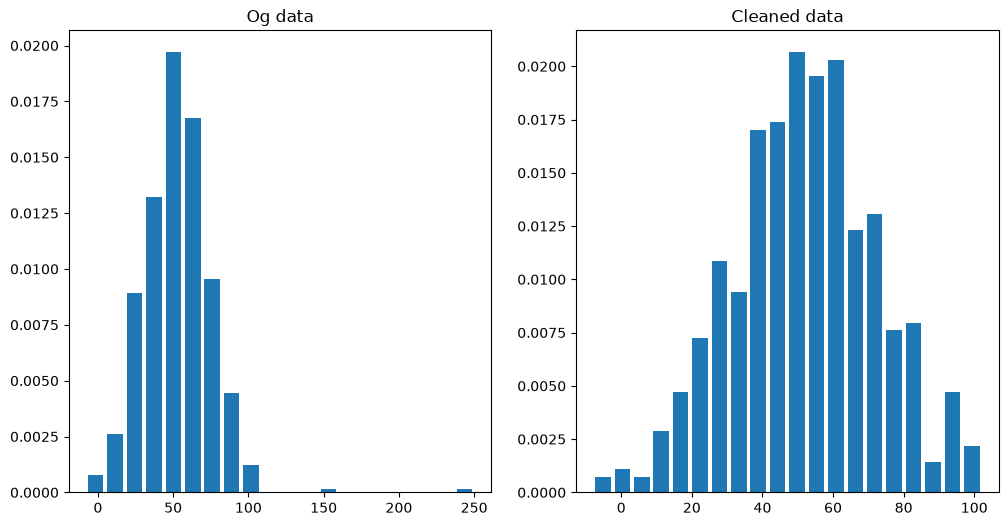

In [20]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.hist(df['Spending_Score'], bins=20, rwidth=0.8, density=True)
plt.title("Og data")

plt.subplot(1,2,2)
plt.hist(df_cleaned_spending_std['Spending_Score'], bins=20, rwidth=0.8, density=True)
plt.title("Cleaned data")

### Z - Score - Age, 3

In [22]:
df_zscore = df.copy()

df_zscore['z_score'] = (df_zscore['Age']- df_zscore['Age'].mean())/df_zscore['Age'].std()
df_zscore.head()

,Age,Income,Spending_Score,z_score
0,39.967142,63892.66321,77.987109,0.479231
1,33.617357,78641.24961,68.492674,-0.139375
2,41.476885,29021.48639,51.192607,0.626312
3,50.230299,58444.53855,37.061264,1.479084
4,32.658466,40240.36146,63.964466,-0.232792


In [24]:
outliers_zscore = df_zscore[(df_zscore['z_score'] < -3) | (df_zscore['z_score'] >3)]
print(outliers_zscore.shape[0])

4


In [25]:
df_zscore_cleaned_age = df_zscore[(df_zscore['z_score'] > -3) & (df_zscore['z_score'] <3)]

Text(0.5, 1.0, 'Cleaned data')

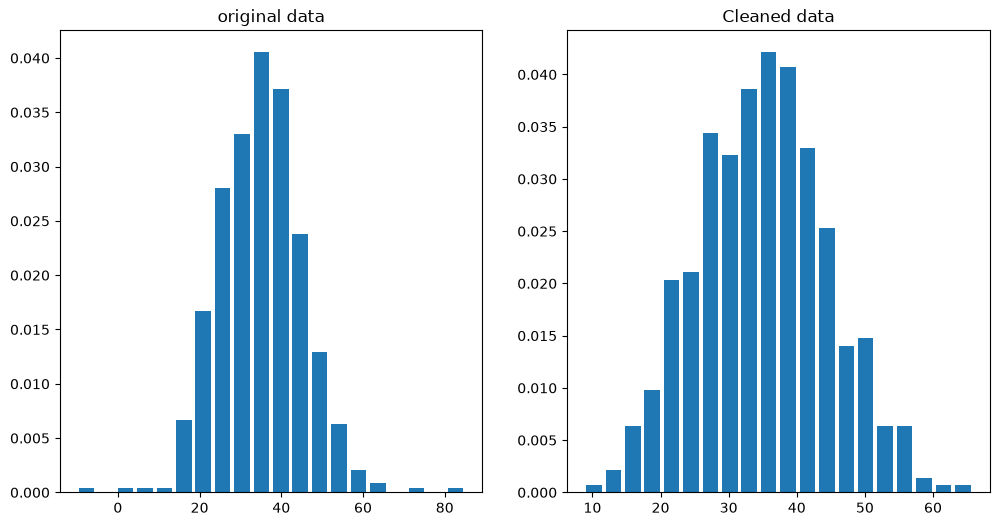

In [38]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.hist(df['Age'], bins=20, rwidth=0.8, density=True)
plt.title("original data")

plt.subplot(1,2,2)
plt.hist(df_zscore_cleaned_age['Age'], bins=20, rwidth=0.8, density=True)
plt.title("Cleaned data")

### IQR - Income

<Axes: xlabel='Income'>

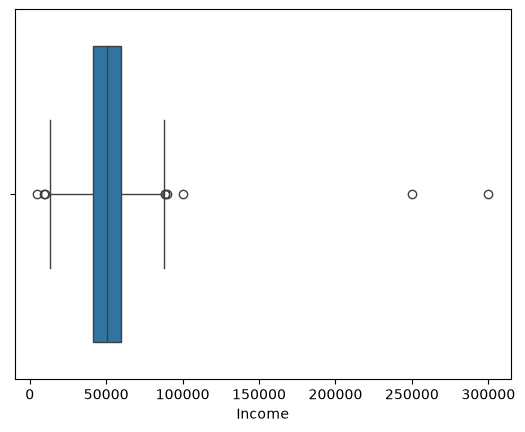

In [27]:
sns.boxplot(x=df['Income'])

In [31]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)

IQR = Q3 - Q1

print(Q1,Q3, IQR)

41070.623905 59939.1961625 18868.572257499996


In [32]:
lower_limit = Q1 - (1.5*IQR)
upper_limit = Q3 + (1.5*IQR)

print(lower_limit, upper_limit)

12767.765518750006 88242.05454874999


In [34]:
outliers_iqr = df[(df['Income'] < lower_limit) | (df['Income'] > upper_limit)]
print(outliers.shape[0])

2


In [35]:
cleaned_df_iqr = df[(df['Income'] > lower_limit) & (df['Income'] < upper_limit)]
cleaned_df_iqr.shape[0]

495

<Axes: xlabel='Income'>

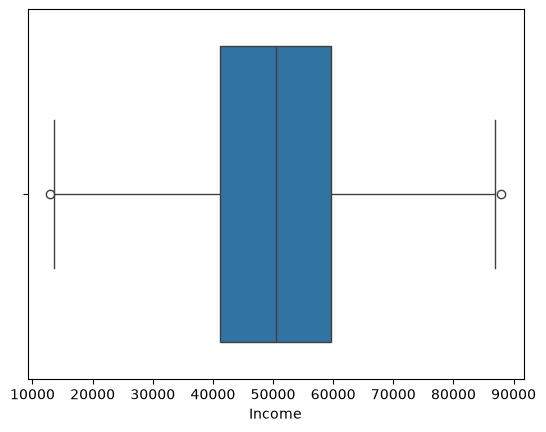

In [36]:
sns.boxplot(x=cleaned_df_iqr['Income'])

Text(0.5, 1.0, 'Cleaned data')

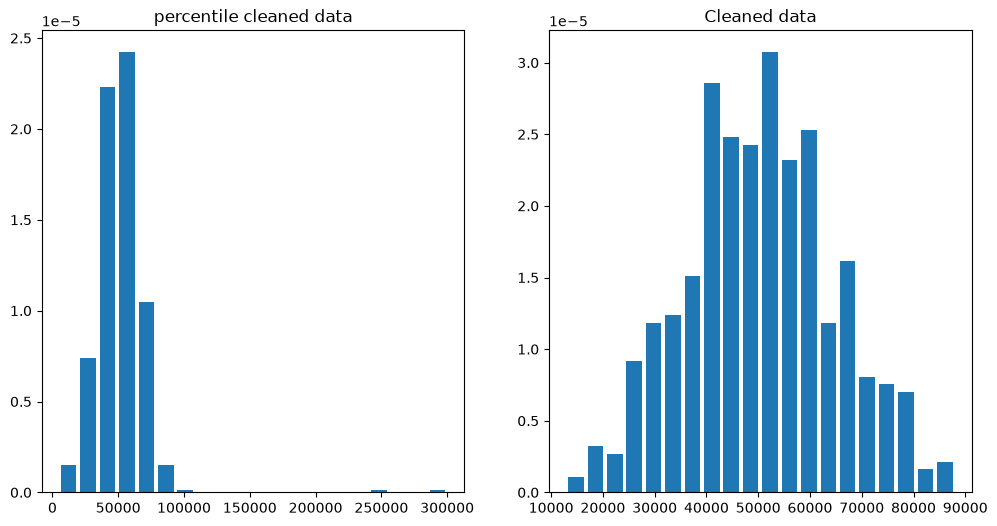

In [37]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.hist(df['Income'], bins=20, rwidth=0.8, density=True)
plt.title("percentile cleaned data")

plt.subplot(1,2,2)
plt.hist(cleaned_df_iqr['Income'], bins=20, rwidth=0.8, density=True)
plt.title("Cleaned data")